In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries as TS


In [ ]:

import urllib.request
from gwosc.locate import get_event_urls
urls = get_event_urls('GW170817', detector='H1', duration=32)
print(urls)

In [ ]:
import h5py

url = 'https://gwosc.org/eventapi/json/GWTC-1-confident/GW170817/v3/H-H1_GWOSC_4KHZ_R1-1187008867-32.hdf5'
urllib.request.urlretrieve(url, 'GW170817_H1.hdf5')

with h5py.File('GW170817_H1.hdf5', 'r') as f:
    def show(name, obj):
        print(name)
    f.visititems(show)

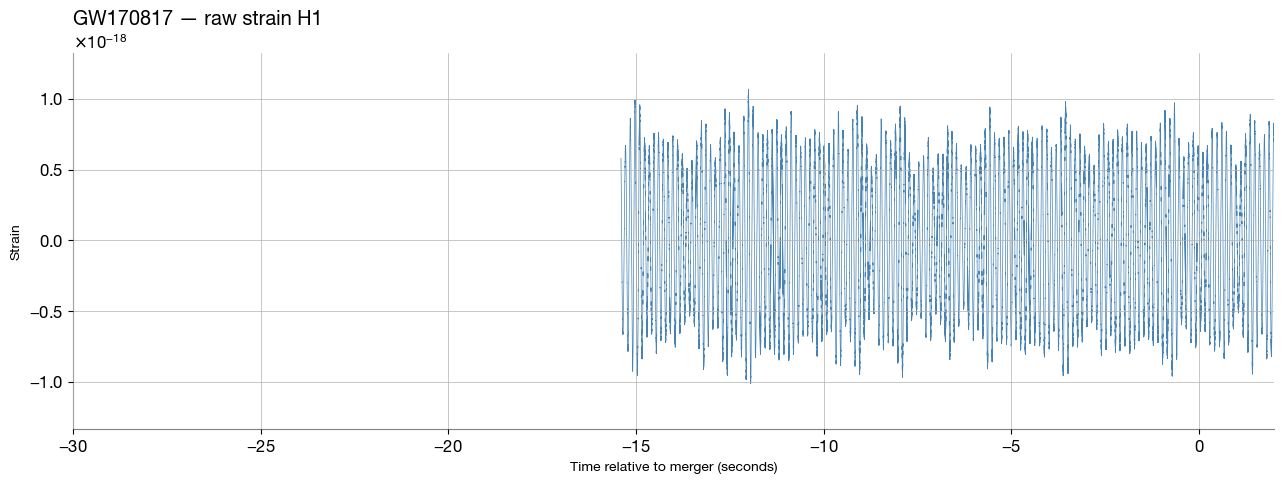

In [15]:
with h5py.File('GW170817_H1.hdf5', 'r') as f:
    strain = f['strain/Strain'][:]
    gps_start = f['meta/GPSstart'][()]
    sample_rate = 4096  # 4KHz file

time = gps_start + np.arange(len(strain)) / sample_rate
gps_event = 1187008882.4
time_centered = time - gps_event

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(time_centered, strain, color='steelblue', linewidth=0.5)
ax.set_xlabel('Time relative to merger (seconds)', fontsize=10)
ax.set_ylabel('Strain', fontsize=10)
ax.set_title('GW170817 — raw strain H1', fontweight='normal', loc='left')
ax.set_xlim(-30, 2)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('GW170817_raw.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
from scipy import signal

# whiten the strain data
# compute the power spectral density
freqs, psd = signal.welch(strain, sample_rate, nperseg=sample_rate*4)

# interpolate PSD to strain frequencies
from scipy.interpolate import interp1d
psd_interp = interp1d(freqs, psd, bounds_error=False, fill_value=1.0)

# whiten in frequency domain
strain_fft = np.fft.rfft(strain)
freqs_fft = np.fft.rfftfreq(len(strain), 1/sample_rate)
psd_vals = psd_interp(freqs_fft)
whitened_fft = strain_fft / np.sqrt(psd_vals)
whitened = np.fft.irfft(whitened_fft)

In [18]:
print(f"File start GPS: {gps_start}")
print(f"File end GPS: {gps_start + len(strain)/sample_rate}")
print(f"Event GPS: 1187008882.4")
print(f"Event relative to file start: {1187008882.4 - gps_start:.1f} seconds")
print(f"Min strain: {strain.min():.3e}")
print(f"Max strain: {strain.max():.3e}")
print(f"Strain std: {strain.std():.3e}")

File start GPS: 1187008867
File end GPS: 1187008899.0
Event GPS: 1187008882.4
Event relative to file start: 15.4 seconds
Min strain: -1.214e-18
Max strain: 1.201e-18
Strain std: 5.329e-19


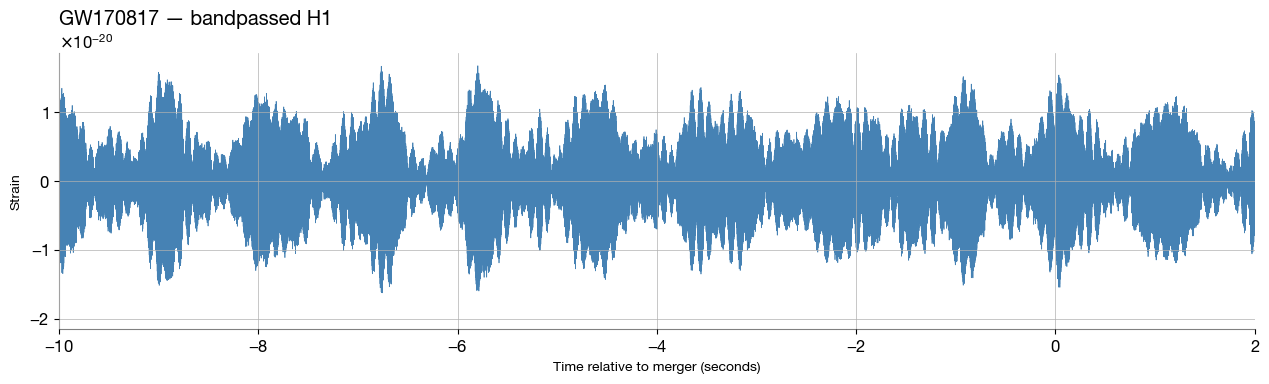

Max bandpassed strain: 1.969e-20


In [20]:
# simpler whitening — just bandpass, no PSD division
b, a = signal.butter(4, [30, 1000], btype='bandpass', fs=sample_rate)
bandpassed = signal.filtfilt(b, a, strain)

# time axis relative to event
time_from_start = np.arange(len(bandpassed)) / sample_rate
time_centered2 = time_from_start - 15.4

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(time_centered2, bandpassed, color='steelblue', linewidth=0.5)
ax.set_xlabel('Time relative to merger (seconds)', fontsize=10)
ax.set_ylabel('Strain', fontsize=10)
ax.set_title('GW170817 — bandpassed H1', fontweight='normal', loc='left')
ax.set_xlim(-10, 2)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('GW170817_bandpassed.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Max bandpassed strain: {np.max(np.abs(bandpassed)):.3e}")

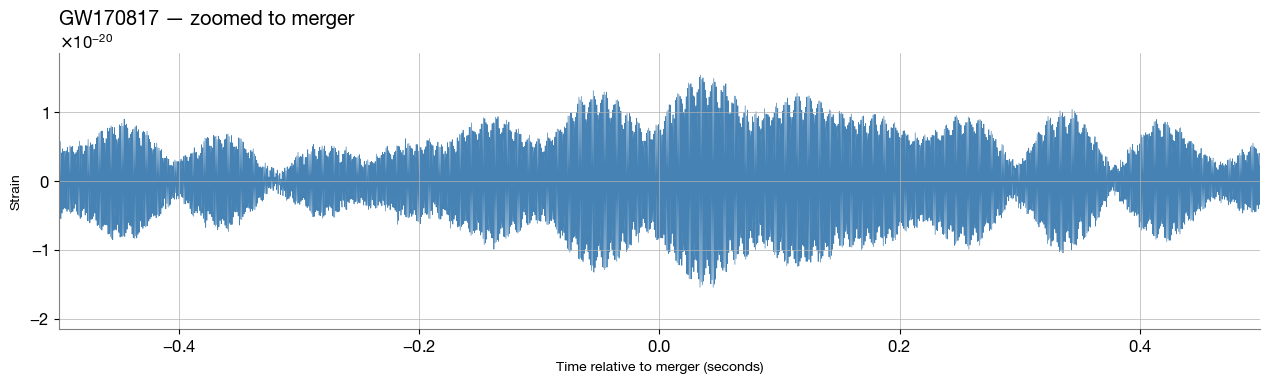

In [25]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(time_centered2, bandpassed, color='steelblue', linewidth=0.5)
ax.set_xlabel('Time relative to merger (seconds)', fontsize=10)
ax.set_ylabel('Strain', fontsize=10)
ax.set_title('GW170817 — zoomed to merger', fontweight='normal', loc='left')
ax.set_xlim(-0.5, 0.5)  # very tight zoom
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('GW170817_zoom.png', dpi=150, bbox_inches='tight')
plt.show()

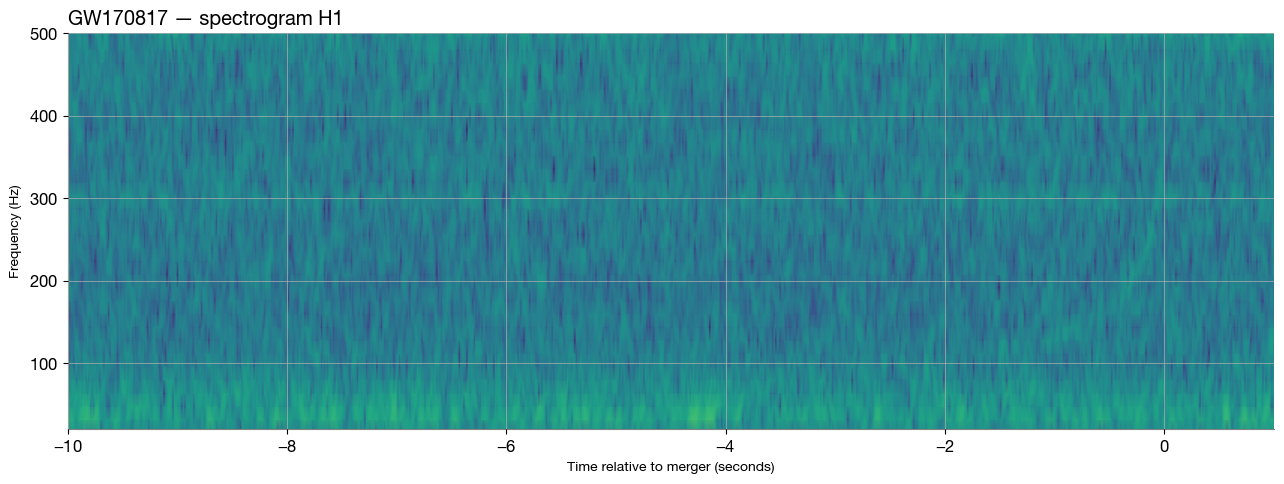

In [26]:
from scipy import signal as sg

f, t, Sxx = sg.spectrogram(bandpassed, fs=sample_rate,
                            nperseg=256, noverlap=200)

t_centered = t - 15.4

fig, ax = plt.subplots(figsize=(13, 5))
ax.pcolormesh(t_centered, f, np.log10(Sxx + 1e-50), 
              cmap='viridis', shading='gouraud')
ax.set_xlabel('Time relative to merger (seconds)', fontsize=10)
ax.set_ylabel('Frequency (Hz)', fontsize=10)
ax.set_title('GW170817 — spectrogram H1', fontweight='normal', loc='left')
ax.set_ylim(20, 500)
ax.set_xlim(-10, 1)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('GW170817_spectrogram.png', dpi=150, bbox_inches='tight')
plt.show()